# Stage 7 — Three-way tracker comparison

Compare exactly three systems over the same contiguous APS segment with one shared Shi–Tomasi initialization and shared frame-k+1 reference detections: frame-only Shi–Tomasi + KLT; event-driven initialization + events + asynchronous updates, with APS used only for scoring; and hybrid event updates followed by one-to-one APS correction. Hybrid correction snaps each matched state's position to its frame reference and advances timestamp, preserving velocity/confidence; unmatched states remain unchanged. All systems use Stage 5's one-to-one greedy endpoint matcher and radius. EPE is matched-only; failures count against feature survival. Lifetime is interval-censored based on consecutive successful APS-reference matches, not identity ground truth. Latency measures differ by primitive operation and are labeled accordingly.

In [2]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "three_way_comparison.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.three_way_comparison as three_way_comparison
three_way_comparison = importlib.reload(three_way_comparison)

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
config = three_way_comparison.ComparisonConfig(
    interval_start=678,
    interval_count=5,
    feature_count=500,
    slot_count=500,
    reference_match_radius_px=15,
)
selected_windows = [
    windows.get_window(i)
    for i in range(config.interval_start, config.interval_start + config.interval_count)
]
result = three_way_comparison.compare_three_systems(selected_windows, config)
outputs = three_way_comparison.save_comparison(
    selected_windows,
    config,
    result,
    three_way_comparison.DEFAULT_OUTPUT_DIR,
)
print(three_way_comparison._comparison_table(result.diagnostics))
print(dict(result.checks))
outputs

| Metric | Frame-only | Event-driven | Hybrid |
|--------|------------|--------------|--------|
| EPE (px) | 4.385 | 4.209 | 4.126 |
| Track lifetime mean (μs) | 108312.9 | 122590.0 | 90863.0 |
| Successfully tracked / interval | 301.0 | 326.8 | 234.4 |
| Failure rate | 39.8000% | 34.6400% | 53.1200% |
| Processing time total (ms) | 1270.65 | 34836.73 | 65515.87 |
| Update latency mean (μs) | 1194.21 | 406.90 | 784.32 |
| Events / useful update | N/A | 49.640 | 69.208 |
| State updates | 1788 | 1791 | 6372 |
| Events processed | 0 | 81112 | 81112 |
{'identical_initial_locations': True, 'identical_frame_intervals': True, 'no_event_use_by_frame_only': True, 'frame_only_klt_output': True, 'event_processing': True, 'event_state_updates': True, 'matching_bounded': True, 'finite_active_event_states': True}


{'results': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/davis_three_way_results.npz'),
 'summary': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/davis_three_way_comparison.json'),
 'per_interval': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/davis_three_way_per_interval.csv'),
 'track_lifetimes': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/davis_three_way_track_lifetimes.csv'),
 'report': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/davis_three_way_comparison_report.md'),
 'epe_distribution': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/three_way_comparison/01_epe_distribution.png'

# Stage 7 — Three-way feature tracking comparison

- Dataset segment: APS intervals 678 through 682.
- Initial features: 500 shared Shi-Tomasi locations.
- Frame interval indices: `[678, 679, 680, 681, 682]`.
- Reference match radius: 15 px.

| Metric | Frame-only | Event-driven | Hybrid |
|--------|------------|--------------|--------|
| EPE (px) | 4.385 | 4.209 | 4.126 |
| Track lifetime mean (μs) | 108312.9 | 122590.0 | 90863.0 |
| Successfully tracked / interval | 301.0 | 326.8 | 234.4 |
| Failure rate | 39.8000% | 34.6400% | 53.1200% |
| Processing time total (ms) | 1270.65 | 34836.73 | 65515.87 |
| Update latency mean (μs) | 1194.21 | 406.90 | 784.32 |
| Events / useful update | N/A | 49.640 | 69.208 |
| State updates | 1788 | 1791 | 6372 |
| Events processed | 0 | 81112 | 81112 |

## Measurement interpretation

EPE uses successful one-to-one greedy matches to next-frame Shi-Tomasi detections only; unmatched tracks contribute to failure rate, not EPE. Feature survival counts consecutive intervals with a successful endpoint match. Mean lifetime is measured from the first frame until the first unmatched interval and is interval-censored; it is a useful-track proxy, not identity ground truth.

Frame-only and event systems have different primitive operations. Frame-only latency is one KLT call per APS interval; event-driven and hybrid latency is association/update-loop wall time per event (including rejected events). Processing time is summed in-memory algorithm plus endpoint evaluation time, but excludes data loading and plots. Do not interpret these latency values as identical hardware operations.

Hybrid APS correction snaps each matched event-updated state to its matched next-frame Shi-Tomasi reference, advances its timestamp, and preserves velocity/confidence. Unmatched states are unchanged. Event-driven APS detections are strictly evaluation-only and do not alter state.

## Correctness checks

| Check | Result |
|---|---|
| Identical Initial Locations | PASS |
| Identical Frame Intervals | PASS |
| No Event Use By Frame Only | PASS |
| Frame Only Klt Output | PASS |
| Event Processing | PASS |
| Event State Updates | PASS |
| Matching Bounded | PASS |
| Finite Active Event States | PASS |

## Scientific scope

This segment comparison can describe the measured operating point only. It does not establish general superiority, cross-sequence performance, motion-compensated accuracy, or statistical significance. The event-driven hypothesis is evaluated by whether its states survive/match at APS boundaries and how accuracy, update counts, and runtime compare; between-frame utility is not directly ground-truthed by APS-only endpoints.


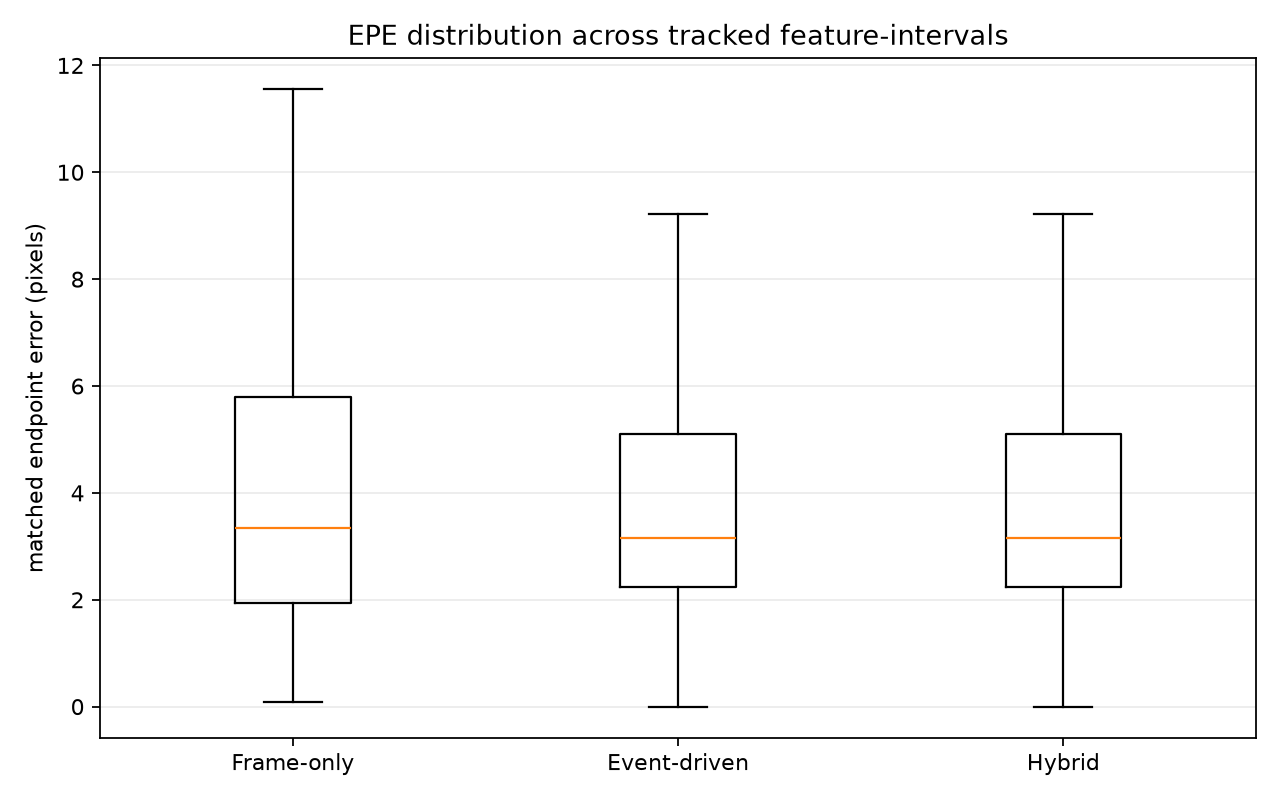

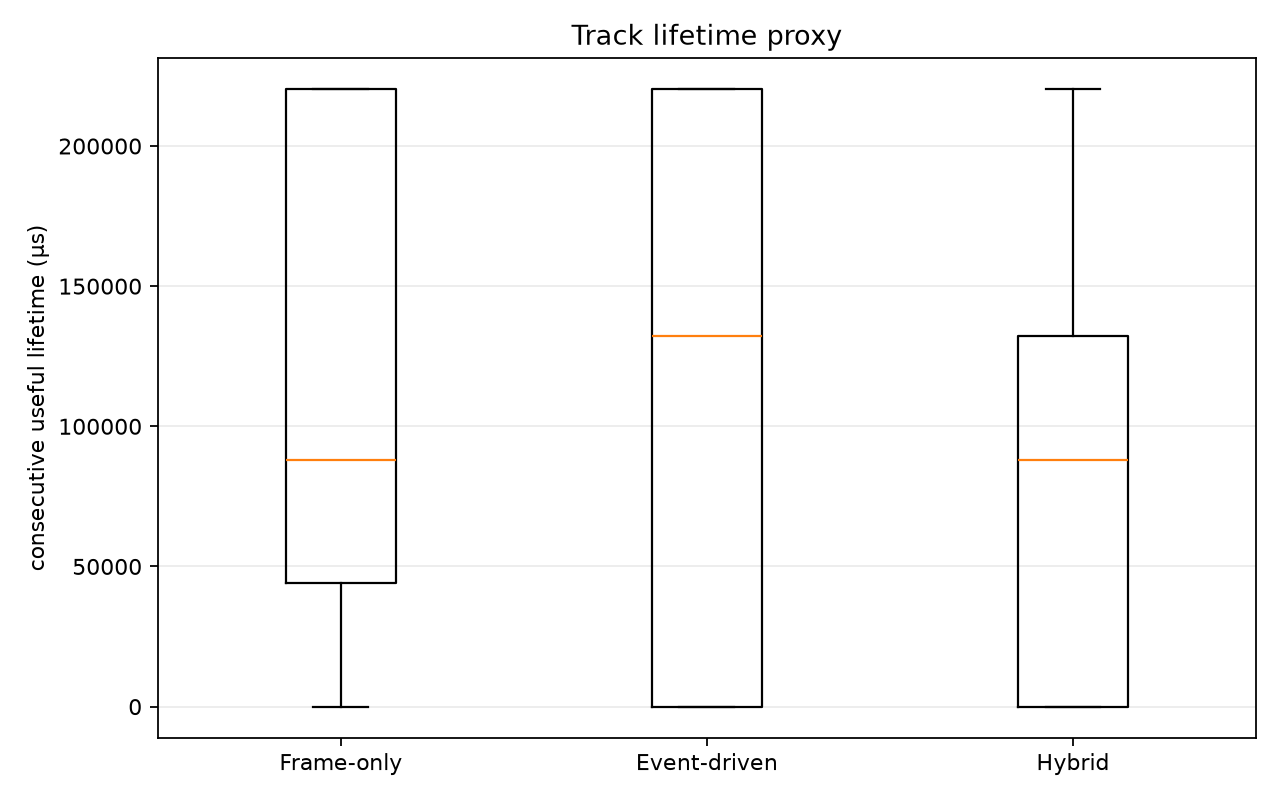

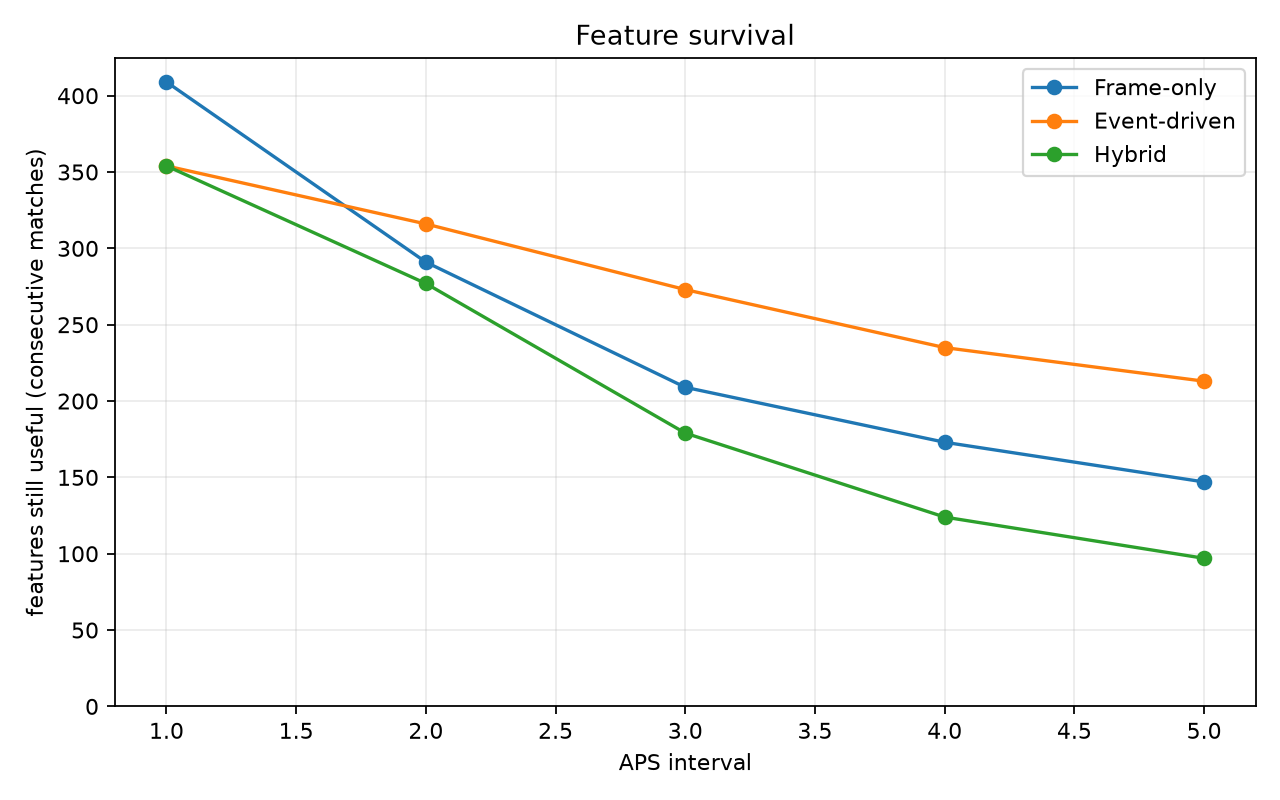

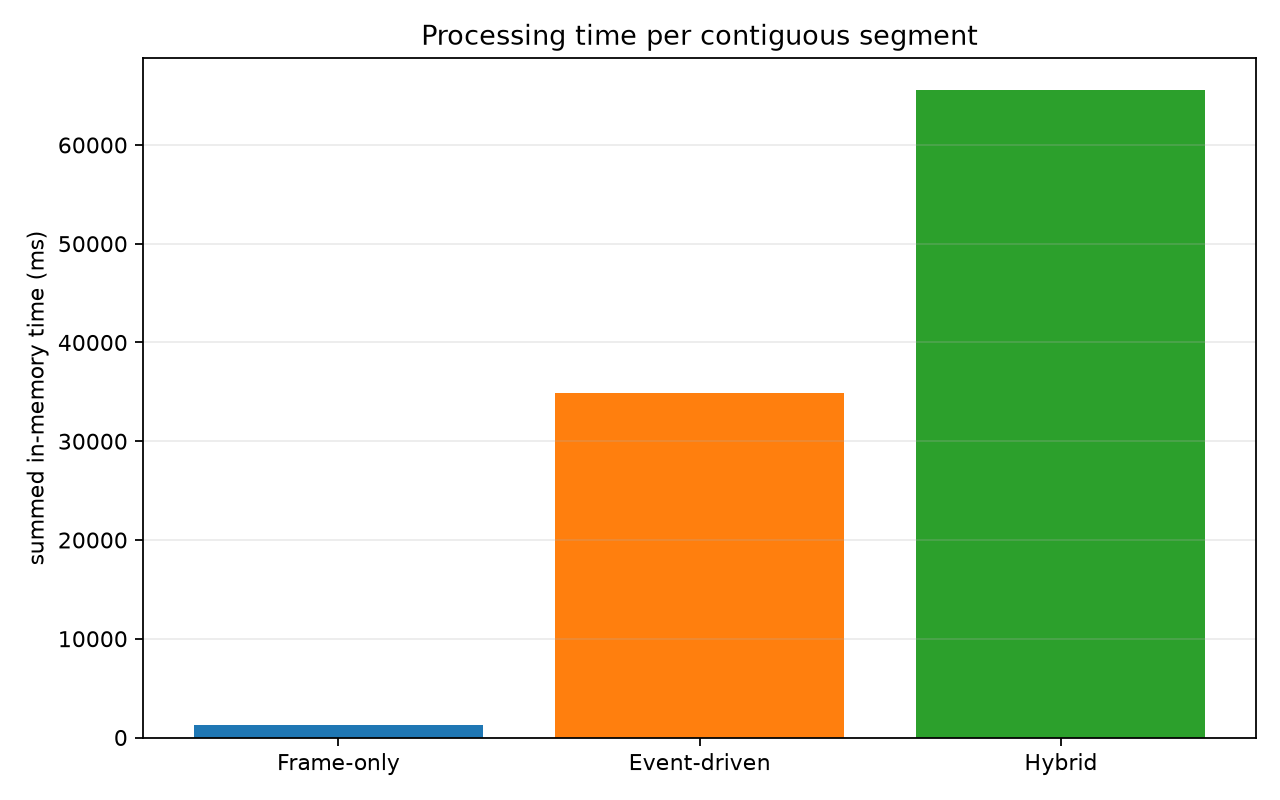

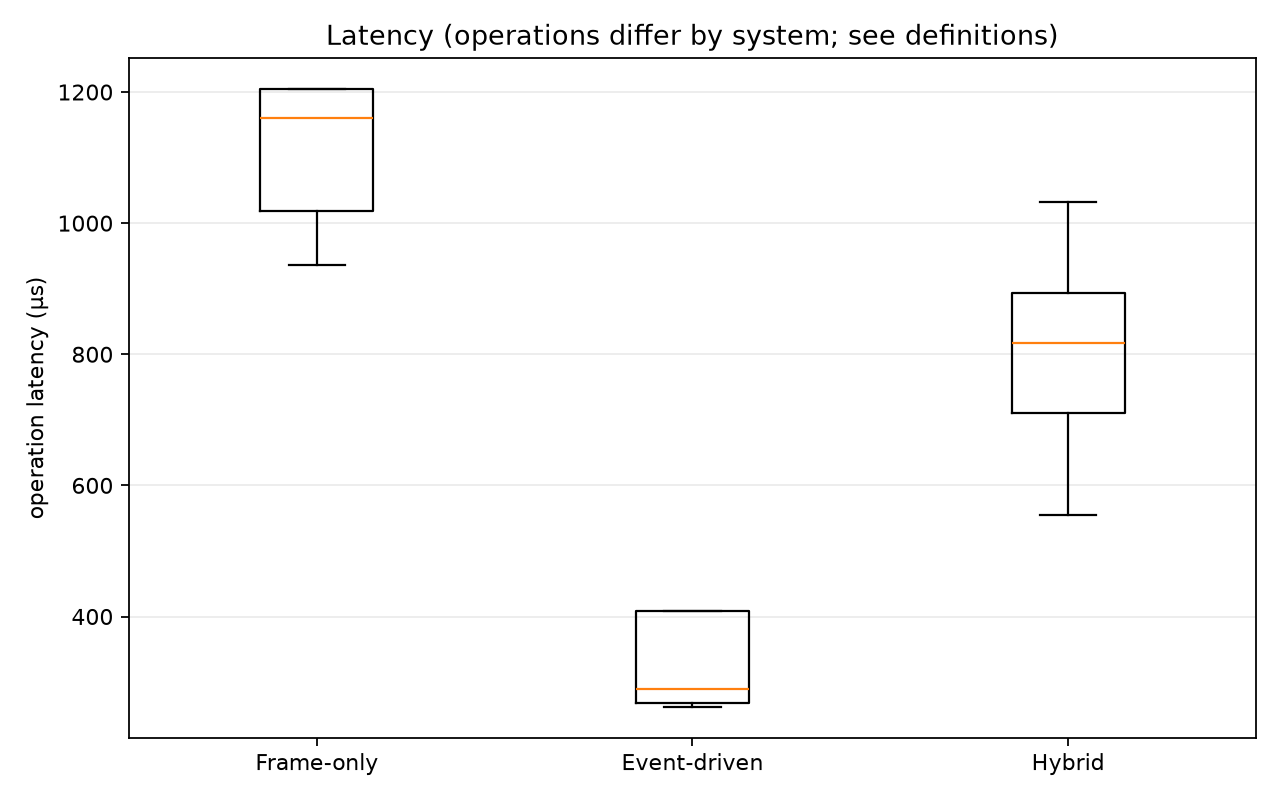

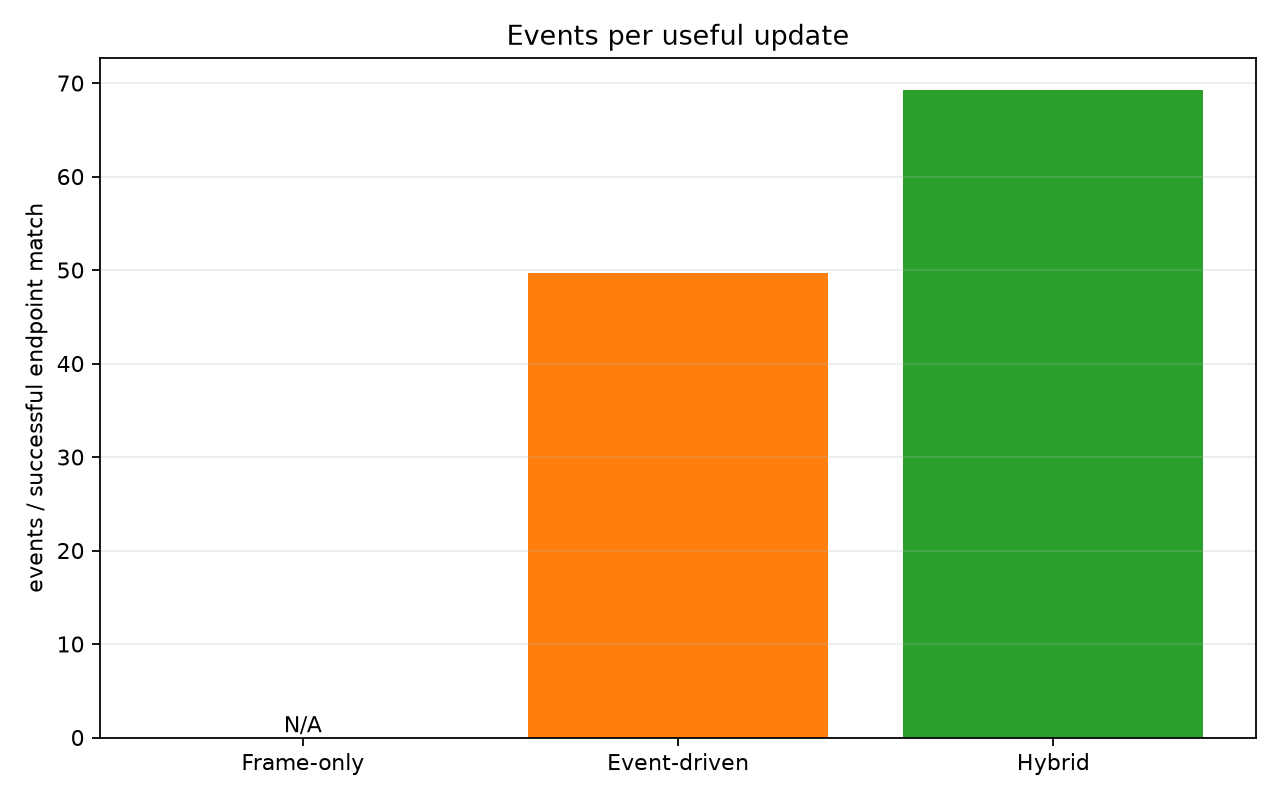

In [3]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
for name in ("epe_distribution", "track_lifetime", "feature_survival", "processing_time", "update_latency", "events_per_update"):
    display(Image(filename=str(outputs[name])))